In [3]:
import pandas as pd
import numpy as np
import os
import zipfile
from google.colab import drive


In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install scikit-learn==1.5.2 coremltools skl2onnx pandas numpy matplotlib scipy --upgrade

✅ Folder ready: /content/drive/MyDrive/FINAL_EXPORT/RF_120
🔹 Step 1: Loading Data
📂 Scanning folders in: /content/drive/MyDrive/motion-sense-dataset/motion_sense_extracted/A_DeviceMotion_data
Found 15 sub-folders.
Data shape: (21528, 128, 12)
🔹 Step 2: Feature Extraction
Feature shape: (21528, 120)
🔹 Step 3: Train/Test Split
🔹 Step 4: Training Random Forest
🔹 Step 5: Evaluation
              precision    recall  f1-score   support

         dws       0.96      0.94      0.95       487
         jog       0.99      0.98      0.99       506
         sit       1.00      1.00      1.00      1305
         std       1.00      1.00      1.00      1179
         ups       0.96      0.96      0.96       587
         wlk       0.98      0.99      0.98      1318

    accuracy                           0.98      5382
   macro avg       0.98      0.98      0.98      5382
weighted avg       0.98      0.98      0.98      5382



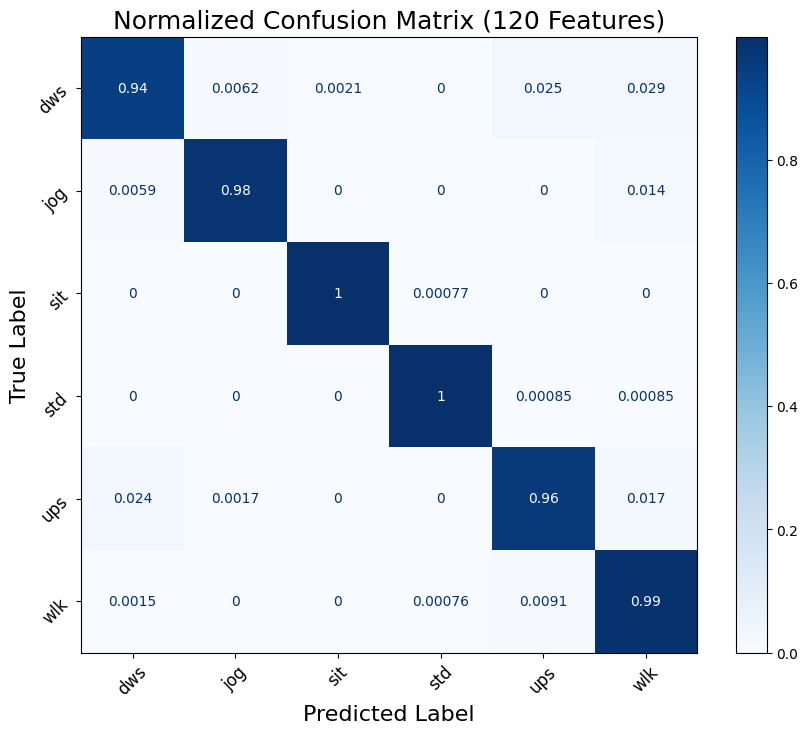

🔹 Step 6: Learning Curve


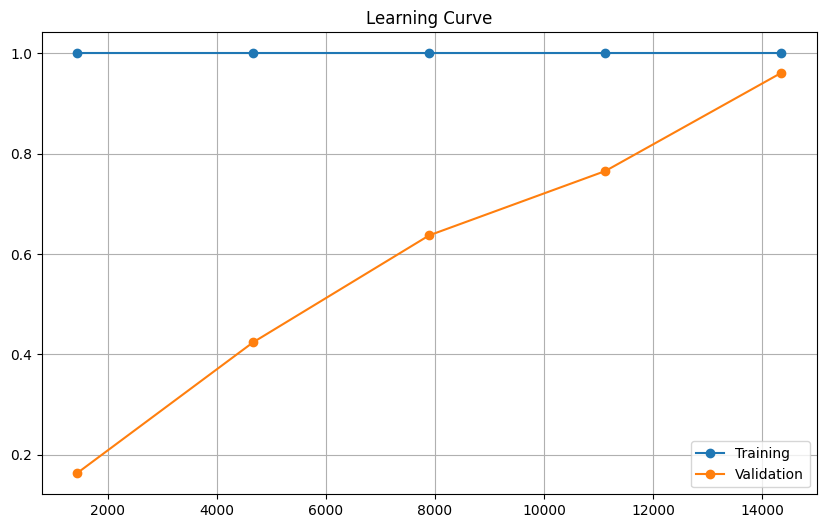

🔹 Step 7: Saving Confusion Matrix
Confusion Matrix saved: /content/drive/MyDrive/FINAL_EXPORT/RF_120/confusion_matrix_120.png
🔹 Step 8: Saving Trained Model
Model saved: /content/drive/MyDrive/FINAL_EXPORT/RF_120/rf_motionsense_120.pkl
🎉 ALL STEPS COMPLETED SUCCESSFULLY


<Figure size 1000x800 with 0 Axes>

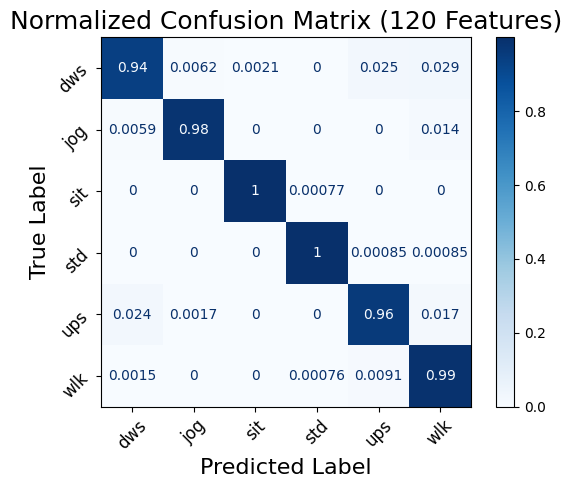

In [6]:
# ==========================================
# 0. Install and Imports
# ==========================================
#!pip install scikit-learn==1.5.2 coremltools pandas numpy matplotlib scipy joblib --upgrade

import os
import glob
import joblib
import numpy as np
import pandas as pd
import coremltools as ct
import matplotlib.pyplot as plt
from scipy.fftpack import fft
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


CONF_MATRIX_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RF_120/'

# Extract folder path
folder_path = os.path.dirname(CONF_MATRIX_PATH)

# Create folder if it does not exist
os.makedirs(folder_path, exist_ok=True)

print("✅ Folder ready:", folder_path)
# ==========================================
# 1. Settings and Paths
# ==========================================

DATASET_PATH = '/content/drive/MyDrive/motion-sense-dataset/motion_sense_extracted/A_DeviceMotion_data'

WINDOW_SIZE = 128
STEP_SIZE = 64

# Save paths
CONF_MATRIX_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RF_120/confusion_matrix_120.png'
MODEL_SAVE_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RF_120/rf_motionsense_120.pkl'

# ==========================================
# 2. Load data from folders
# ==========================================

def load_data_from_folders(root_path):

    print(f"📂 Scanning folders in: {root_path}")

    X_windows = []
    y_labels = []

    subfolders = sorted(glob.glob(os.path.join(root_path, '*')))
    print(f"Found {len(subfolders)} sub-folders.")

    for folder in subfolders:

        folder_name = os.path.basename(folder)

        if '_' in folder_name:
            label = folder_name.split('_')[0]
        else:
            continue

        csv_files = glob.glob(os.path.join(folder, '*.csv'))

        for file_path in csv_files:

            try:

                df = pd.read_csv(file_path)

                if 'Unnamed: 0' in df.columns:
                    df = df.drop(columns=['Unnamed: 0'])

                required_cols = [
                    'attitude.roll','attitude.pitch','attitude.yaw',
                    'gravity.x','gravity.y','gravity.z',
                    'rotationRate.x','rotationRate.y','rotationRate.z',
                    'userAcceleration.x','userAcceleration.y','userAcceleration.z'
                ]

                if all(col in df.columns for col in required_cols):
                    data = df[required_cols].values
                else:
                    data = df.iloc[:, :12].values

                for start in range(0,len(data)-WINDOW_SIZE,STEP_SIZE):

                    end = start + WINDOW_SIZE

                    if end <= len(data):

                        X_windows.append(data[start:end])
                        y_labels.append(label)

            except Exception:
                pass

    return np.array(X_windows), np.array(y_labels)

# ==========================================
# 3. Extract 120 features
# ==========================================

def extract_120_features(window):

    features = []

    for i in range(window.shape[1]):

        signal = window[:,i]

        # time-domain
        features.extend([
            np.mean(signal),
            np.std(signal),
            np.max(signal),
            np.min(signal),
            np.median(signal),
            np.mean(np.abs(signal)),
            np.mean(signal**2)
        ])

        # frequency-domain
        n = len(signal)

        fft_coeffs = np.abs(fft(signal))[:n//2]

        if np.sum(fft_coeffs) == 0:

            features.extend([0,0,0])

        else:

            psd_norm = fft_coeffs/(np.sum(fft_coeffs)+1e-9)

            entropy = -np.sum(psd_norm*np.log2(psd_norm+1e-9))

            features.extend([
                np.argmax(fft_coeffs),
                np.mean(fft_coeffs**2),
                entropy
            ])

    return np.array(features)

# ==========================================
# 4. Run pipeline
# ==========================================

if not os.path.exists(DATASET_PATH):

    print("❌ Dataset path not found")

else:

    print("🔹 Step 1: Loading Data")

    X_raw , y_labels = load_data_from_folders(DATASET_PATH)

    print("Data shape:",X_raw.shape)

    print("🔹 Step 2: Feature Extraction")

    X_features = np.array([extract_120_features(w) for w in X_raw])

    print("Feature shape:",X_features.shape)

    print("🔹 Step 3: Train/Test Split")

    X_train,X_test,y_train,y_test = train_test_split(
        X_features,
        y_labels,
        test_size=0.25,
        stratify=y_labels,
        random_state=42
    )

    print("🔹 Step 4: Training Random Forest")

    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train,y_train)

    # ==========================================
    # Step 5: Evaluation & Confusion Matrix
    # ==========================================

    print("🔹 Step 5: Evaluation")

    y_pred = rf_model.predict(X_test)

    print(classification_report(y_test,y_pred))

    fig,ax = plt.subplots(figsize=(10,8))

    disp = ConfusionMatrixDisplay.from_estimator(
        rf_model,
        X_test,
        y_test,
        cmap=plt.cm.Blues,
        normalize='true',
        ax=ax
    )

    ax.set_title("Normalized Confusion Matrix (120 Features)",fontsize=18)
    ax.set_xlabel("Predicted Label",fontsize=16)
    ax.set_ylabel("True Label",fontsize=16)

    plt.xticks(rotation=45,fontsize=12)
    plt.yticks(rotation=45,fontsize=12)

    plt.show()

    # ==========================================
    # Step 6: Learning Curve
    # ==========================================

    print("🔹 Step 6: Learning Curve")

    train_sizes,train_scores,test_scores = learning_curve(
        rf_model,
        X_features,
        y_labels,
        cv=3,
        n_jobs=-1,
        train_sizes=np.linspace(0.1,1.0,5)
    )

    plt.figure(figsize=(10,6))

    plt.plot(train_sizes,np.mean(train_scores,axis=1),'o-',label="Training")
    plt.plot(train_sizes,np.mean(test_scores,axis=1),'o-',label="Validation")

    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)

    plt.show()

    # ==========================================
    # Step 7: Save Confusion Matrix
    # ==========================================

    print("🔹 Step 7: Saving Confusion Matrix")

    cm = confusion_matrix(y_test,y_pred,normalize='true')

    plt.figure(figsize=(10,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=rf_model.classes_
    )

    disp.plot(cmap=plt.cm.Blues)

    plt.title("Normalized Confusion Matrix (120 Features)",fontsize=18)
    plt.xlabel("Predicted Label",fontsize=16)
    plt.ylabel("True Label",fontsize=16)

    plt.xticks(rotation=45,fontsize=12)
    plt.yticks(rotation=45,fontsize=12)

    plt.savefig(CONF_MATRIX_PATH,dpi=300,bbox_inches='tight')

    print("Confusion Matrix saved:",CONF_MATRIX_PATH)

    # ==========================================
    # Step 8: Save trained model
    # ==========================================

    print("🔹 Step 8: Saving Trained Model")

    os.makedirs(os.path.dirname(MODEL_SAVE_PATH),exist_ok=True)

    joblib.dump(rf_model,MODEL_SAVE_PATH)

    print("Model saved:",MODEL_SAVE_PATH)

    print("🎉 ALL STEPS COMPLETED SUCCESSFULLY")

In [7]:
# ==========================================
# Step 8: CoreML Conversion Code (Force Sklearn Converter)
# ==========================================
import coremltools as ct
import joblib
import os
import sklearn
from google.colab import drive



# Paths
PKL_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RF_120/rf_motionsense_120.pkl'
COREML_SAVE_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RF_120/MotionSense_120.mlpackage'

print(f"📂 Loading model from: {PKL_PATH}")
if not os.path.exists(PKL_PATH):
    print("❌ Error: PKL file not found!")
else:
    # Load the trained model
    rf_model = joblib.load(PKL_PATH)
    print("✅ Model Loaded.")
    print(f"   Type: {type(rf_model)}")

    # Define model input (120 features)
    features_input = [("features", ct.models.datatypes.Array(120))]

    print("🔄 Converting using Explicit Sklearn Converter...")

    # --- Important change: use direct sklearn converter ---
    try:
        # Method 1: use the dedicated sklearn converter
        # (helps bypass source detection errors)
        coreml_model = ct.converters.sklearn.convert(
            rf_model,
            input_features="features",
            output_feature_names="classLabel"
        )
    except AttributeError:
        # Method 2: fallback to standard ct.convert
        # usually method 1 works well for Random Forest models
        print("⚠️ Falling back to standard convert...")
        coreml_model = ct.convert(rf_model)

    # Metadata configuration
    coreml_model.short_description = "MotionSense Random Forest (120 Features)"
    coreml_model.input_description["features"] = "Input Vector (Size 120)"
    coreml_model.output_description["classLabel"] = "Predicted Activity"
    coreml_model.author = "Amir"

    # Save the CoreML model
    if os.path.exists(COREML_SAVE_PATH):
        import shutil
        shutil.rmtree(COREML_SAVE_PATH)  # remove previous version if corrupted

    coreml_model.save(COREML_SAVE_PATH)
    print(f"✅ CoreML Model Saved Successfully: {COREML_SAVE_PATH}")
    print("🎉 Done!")

📂 Loading model from: /content/drive/MyDrive/FINAL_EXPORT/RF_120/rf_motionsense_120.pkl
✅ Model Loaded.
   Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
🔄 Converting using Explicit Sklearn Converter...
✅ CoreML Model Saved Successfully: /content/drive/MyDrive/FINAL_EXPORT/RF_120/MotionSense_120.mlpackage
🎉 Done!
